In [1]:
import gzip
import io
import os
import pickle
from collections import Counter

import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pymatviz
import requests
import seaborn as sns
from colorama import Fore, Style
from huggingface_hub import hf_hub_download
from matplotlib import pyplot as plt
from mp_api.client import MPRester
from pymatgen.entries.computed_entries import ComputedEntry
from pymatgen.io.cif import CifParser
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from smact.screening import smact_validity
from tabulate import tabulate

from xtalmet.constants import HF_VERSION
from xtalmet.crystal import Crystal
from xtalmet.stability import StabilityCalculator

/rds/general/user/mn825/home/proj/xtalmet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
MP_API_KEY = "8yBcy0i5ySkJSYQGcek8BPGQwARrk2Hs"

In [ ]:
# Constants
MODELS = [
	"cdvae",
	"diffcsp",
	"diffcsppp",
	"mattergen",
	"chemeleon",
	"adit",
	"chemeleon2",
]
MODELS_TEST = MODELS + ["test"]
MODELS_RL = [
	"chemeleon2",
	"chemeleon2_rl_bsun",
	"chemeleon2_rl_csun",
	"chemeleon2_rl_csun_u10",
]
MODELS_RL_TEST = MODELS_RL + ["test"]

MODELS_ALL = [
	"cdvae",
	"diffcsp",
	"diffcsppp",
	"mattergen",
	"chemeleon",
	"adit",
	"chemeleon2",
	"chemeleon2_rl_bsun",
	"chemeleon2_rl_csun",
	"chemeleon2_rl_csun_u10",
]
MODELS_ALL_TEST = MODELS_ALL + ["test"]
BINARY_DISTANCES = ["smat", "comp", "wyckoff"]
CONTINUOUS_DISTANCES = ["elmd", "amd", "elmd+amd"]
DISTANCES = ["comp", "elmd", "wyckoff", "amd", "smat", "elmd+amd"]

RESULTS_DIR = os.path.join(os.getcwd(), "results", "mp20")
FIGURES_DIR = os.path.join(os.getcwd(), "figures")
PREPROCESS_DIR = os.path.join(os.getcwd(), "preprocess")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PREPROCESS_DIR, exist_ok=True)

STABILITY_INTERCEPT = 0.4289


In [4]:
# Set plotting style
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

GRAY = "#9FA0A0"
BLACK = "#000000"
WHITE = "#FFFFFF"
sns.set_palette(
	[
		"#316745",
		"#F39800",
		"#2CA9E1",
		"#c53d43",
		"#B8D200",
		"#19448E",
		"#884898",
		GRAY,
		"#E597B2",
	]
)

FIG_WIDTH = 6.0248  # 7.5
FONT_LL = 12
FONT_L = 10
FONT_M = 8
FONT_S = 6
FONT_SS = 4
PAD_L = 10
PAD_M = 7
PAD_S = 4
PAD_SS = 2

DISTANCE_LABELS = {
	"comp": r"$d_\mathrm{comp}$",
	"elmd": r"$d_\mathrm{elm}$",
	"wyckoff": r"$d_\mathrm{wyckoff}$",
	"amd": r"$d_\mathrm{am}$",
	"smat": r"$d_\mathrm{smat}$",
	"elmd+amd": r"$d_\mathrm{elm{+}am}$",
}
U_LABELS = {
	"comp": r"$\overline{\mathrm{U}}_\mathrm{comp}$",
	"elmd": r"$\overline{\mathrm{U}}_\mathrm{elm}$",
	"wyckoff": r"$\overline{\mathrm{U}}_\mathrm{wyckoff}$",
	"amd": r"$\overline{\mathrm{U}}_\mathrm{am}$",
	"smat": r"$\overline{\mathrm{U}}_\mathrm{smat}$",
	"elmd+amd": r"$\overline{\mathrm{U}}_\mathrm{elm{+}am}$",
}
N_LABELS = {
	"comp": r"$\overline{\mathrm{N}}_\mathrm{comp}$",
	"elmd": r"$\overline{\mathrm{N}}_\mathrm{elm}$",
	"wyckoff": r"$\overline{\mathrm{N}}_\mathrm{wyckoff}$",
	"amd": r"$\overline{\mathrm{N}}_\mathrm{am}$",
	"smat": r"$\overline{\mathrm{N}}_\mathrm{smat}$",
	"elmd+amd": r"$\overline{\mathrm{N}}_\mathrm{elm{+}am}$",
}
SUN_LABELS = {
	"comp": r"$\overline{\mathrm{SUN}}_\mathrm{comp}$",
	"elmd": r"$\overline{\mathrm{SUN}}_\mathrm{elm}$",
	"wyckoff": r"$\overline{\mathrm{SUN}}_\mathrm{wyckoff}$",
	"amd": r"$\overline{\mathrm{SUN}}_\mathrm{am}$",
	"smat": r"$\overline{\mathrm{SUN}}_\mathrm{smat}$",
	"elmd+amd": r"$\overline{\mathrm{SUN}}_\mathrm{elm{+}am}$",
}
MODEL_TEST_LABELS = {
	"cdvae": "CDVAE",
	"diffcsp": "DiffCSP",
	"diffcsppp": "DiffCSP++",
	"mattergen": "MatterGen",
	"chemeleon": "Chemeleon-DNG",
	"adit": "ADiT",
	"chemeleon2": "Chemeleon2",
	"test": "MP20 Test Set",
}
MODEL_RL_TEST_LABELS = {
	"chemeleon2": "Default",
	"chemeleon2_rl_bsun": SUN_LABELS["smat"],
	"chemeleon2_rl_csun": SUN_LABELS["elmd+amd"],
	"chemeleon2_rl_csun_u10": rf"{SUN_LABELS['elmd+amd']} ($w_U=10$)",
	"test": "MP20 Test Set",
}

# 1. Preprocessing

In [5]:
def load_gz(path):
	with gzip.open(path, "rb") as f:
		return pickle.load(f)


def dump_gz(path, data):
	with gzip.open(path, "wb") as f:
		pickle.dump(data, f)


def load_or_compute_gz(path, compute_fn):
	if os.path.exists(path):
		return load_gz(path)
	data = compute_fn()
	dump_gz(path, data)
	return data

In [6]:
# Load generated samples (for visualizations in Figures 5 and 11 of the paper)
SAMPLES = {}
for model in ["cdvae", "mattergen"]:
	path = hf_hub_download(
		repo_id="masahiro-negishi/xtalmet",
		filename=f"mp20/model/{model}.pkl.gz",
		repo_type="dataset",
		revision=HF_VERSION,
	)
	SAMPLES[model] = load_gz(path)


In [7]:
# Load training samples
def _compute_train_samples():
	url = "https://raw.githubusercontent.com/txie-93/cdvae/refs/heads/main/data/mp_20/train.csv"
	response = requests.get(url)
	train_samples_raw = pd.read_csv(io.StringIO(response.content.decode("utf-8")))
	return [
		Crystal.from_Structure(
			CifParser.from_str(row["cif"]).parse_structures(primitive=True)[0]
		)
		for _, row in train_samples_raw.iterrows()
	]


TRAIN_SAMPLES = load_or_compute_gz(
	os.path.join(PREPROCESS_DIR, "train_samples.pkl.gz"),
	_compute_train_samples,
)


In [8]:
def _score_uniqueness(mtx, distance):
	if distance in BINARY_DISTANCES:
		return np.array([np.all(mtx[i, :i] != 0) for i in range(len(mtx))], dtype=float)
	return np.sum(mtx, axis=1) / (len(mtx) - 1)


def _score_novelty(mtx, distance):
	validity_ref = np.array([v != float("nan") for v in mtx[0]])
	if distance in BINARY_DISTANCES:
		return np.array(
			[
				np.all(np.logical_or(~validity_ref, mtx[i] != 0))
				for i in range(len(mtx))
			],
			dtype=float,
		)
	mtx[:, ~validity_ref] = float("inf")
	return np.min(mtx, axis=1)


def load_score_df(csv_path, score_col, mtx_prefix, score_fn):
	if os.path.exists(csv_path):
		return pd.read_csv(csv_path)
	records = []
	for model in MODELS_ALL_TEST:
		for distance in DISTANCES:
			print(f"model: {model}, distance: {distance}")
			mtx = load_gz(
				os.path.join(RESULTS_DIR, model, f"{mtx_prefix}_{distance}.pkl.gz")
			)
			for s in score_fn(mtx, distance):
				records.append({"Model": model, "Distance": distance, score_col: s})
	df = pd.DataFrame(records)
	df.to_csv(csv_path, index=False)
	return df


In [9]:
# Load uniqueness scores
path_uni = os.path.join(PREPROCESS_DIR, "uni.csv")
df_uni = load_score_df(path_uni, "Uniqueness score", "mtx_uni", _score_uniqueness)


In [10]:
# Load novelty scores
path_nov = os.path.join(PREPROCESS_DIR, "nov.csv")
df_nov = load_score_df(path_nov, "Novelty score", "mtx_nov", _score_novelty)


In [11]:
# Load energy above hull values for experimentally synthesized entries in MP
def _compute_ehulls_mp_experimental():
	mpr = MPRester(MP_API_KEY)
	docs = mpr.summary.search(
		theoretical=False, fields=["energy_above_hull"]
	)  # 49283 samples
	return [doc.energy_above_hull for doc in docs]


ehulls_mp_experimental = load_or_compute_gz(
	os.path.join(PREPROCESS_DIR, "ehull_mp_experimental.pkl.gz"),
	_compute_ehulls_mp_experimental,
)


In [12]:
# Load energy above hull values for CDVAE MP20 test set
def _compute_ehulls_mp20_test():
	url = "https://raw.githubusercontent.com/txie-93/cdvae/refs/heads/main/data/mp_20/test.csv"
	response = requests.get(url)
	test_xtals_raw = pd.read_csv(io.StringIO(response.content.decode("utf-8")))
	test_xtals = []
	for _, row in test_xtals_raw.iterrows():
		structure = CifParser.from_str(row["cif"]).parse_structures(primitive=True)[0]
		test_xtals.append(Crystal.from_Structure(structure))
	ids_mp20 = test_xtals_raw["material_id"].tolist()
	id2idx_mp20 = {id: i for i, id in enumerate(ids_mp20)}
	energy_mp20 = np.full(len(ids_mp20), np.nan)
	with MPRester(MP_API_KEY) as mpr:
		docs_now = mpr.materials.thermo.search(
			material_ids=ids_mp20,
			thermo_types=["GGA_GGA+U"],
			fields=["material_id", "uncorrected_energy_per_atom"],
		)
		ids_mp_now = [doc.material_id for doc in docs_now]
		for doc in docs_now:
			energy_mp20[id2idx_mp20[doc.material_id]] = doc.uncorrected_energy_per_atom
		for id in ids_mp20:
			if id in ids_mp_now:
				continue
			formula = test_xtals_raw[test_xtals_raw["material_id"] == id][
				"pretty_formula"
			].values[0]
			docs_same_formula = mpr.materials.summary.search(
				formula=[formula],
				fields=[
					"material_id",
					"formula_pretty",
					"task_ids",
					"uncorrected_energy_per_atom",
				],
			)
			for doc in docs_same_formula:
				if doc.task_ids and id in doc.task_ids:
					docs_task = mpr.materials.thermo.search(
						material_ids=[str(doc.material_id)],
						thermo_types=["GGA_GGA+U"],
						fields=["material_id", "uncorrected_energy_per_atom"],
					)
					if len(docs_task) != 0:
						energy_mp20[id2idx_mp20[id]] = docs_task[
							0
						].uncorrected_energy_per_atom
					break
	print(f"Total structures in CDVAE mp20 test set: {len(ids_mp20)}")  # 9046
	print(
		f"Structures with uncorrected energy: {np.sum(~np.isnan(energy_mp20))}"
	)  # 8797
	stability_calculator = StabilityCalculator()
	ehulls = np.full(len(ids_mp20), np.nan)
	for i, energy in enumerate(energy_mp20):
		if not np.isnan(energy):
			try:
				comp = test_xtals[i].get_composition_pymatgen()
				entry = ComputedEntry(comp, energy * comp.num_atoms)
				ehulls[i] = stability_calculator.ppd_mp.get_e_above_hull(
					entry, allow_negative=True
				)
			except ValueError:
				ehulls[i] = np.nan
	print(f"Computed e_above_hulls for {np.sum(~np.isnan(ehulls))} structures")  # 8797
	return ehulls


ehulls_mp20_test = load_or_compute_gz(
	os.path.join(PREPROCESS_DIR, "ehull_mp20_test.pkl.gz"),
	_compute_ehulls_mp20_test,
)


# 2. Figures and Tables

In [13]:
def table_ranking(df, col_score, model_list):
	headers = ["model"] + model_list
	rows = []
	for distance in DISTANCES:
		row = []
		for model in model_list:
			scores = df[(df["Model"] == model) & (df["Distance"] == distance)][
				col_score
			].values
			scores[np.isnan(scores)] = 0.0
			row.append(np.mean(scores).item())
		rows.append(row)
	ranks = np.argsort(-np.array(rows)[:, :-1], axis=1)
	rows_highlighted = []
	for i in range(len(rows)):
		row_highlighted = [None for _ in range(len(rows[i]))]
		for j in range(len(rows[i]) - 1):
			RANK_COLORS = [Fore.RED, Fore.GREEN, Fore.YELLOW]
			color = RANK_COLORS[j] if j < len(RANK_COLORS) else None
			if j <= 2:
				cell_str = (
					color
					+ Style.BRIGHT
					+ f"{rows[i][ranks[i][j]]:.4f} ({j + 1})"
					+ Style.RESET_ALL
				)
			else:
				cell_str = f"{rows[i][ranks[i][j]]:.4f} ({j + 1})"
			row_highlighted[ranks[i][j]] = cell_str
		row_highlighted[-1] = f"{rows[i][-1]:.4f}"
		rows_highlighted.append(row_highlighted)
	print(
		tabulate(
			[[DISTANCES[i]] + row for i, row in enumerate(rows_highlighted)],
			headers=headers,
			tablefmt="grid",
		)
	)

In [14]:
def stripplot(df, col_score, filename, label_dict):
	models = []
	distances = []
	scores = []
	for model in MODELS_TEST:
		for distance in DISTANCES:
			models.append(model)
			distances.append(distance)
			scores_sub = df[(df["Model"] == model) & (df["Distance"] == distance)][
				col_score
			].values
			scores_sub[np.isnan(scores_sub)] = 0.0
			scores.append(np.mean(scores_sub).item())
	df = pd.DataFrame({"Model": models, "Distance": distances, col_score: scores})

	fig, axes = plt.subplots(
		1,
		len(DISTANCES),
		figsize=(FIG_WIDTH, 0.3 * FIG_WIDTH),
		gridspec_kw={"wspace": 0.05},
	)
	handles, labels = None, None
	for i, distance in enumerate(DISTANCES):
		ax = axes[i]
		sns.stripplot(
			data=df[(df["Distance"] == distance) & (df["Model"] != "test")],
			y=col_score,
			hue="Model",
			dodge=True,
			size=6.5,
			edgecolor=BLACK,
			linewidth=1,
			ax=ax,
		)
		test_score = df[(df["Distance"] == distance) & (df["Model"] == "test")][
			col_score
		].values[0]
		ax.axhline(
			y=test_score, color=GRAY, linestyle="--", label="test", dashes=(2, 1)
		)
		y_data = df[(df["Distance"] == distance)][col_score].values
		max_val = y_data.max()
		min_val = y_data.min()
		margin = max(abs(max_val - test_score), abs(min_val - test_score))
		ax.set_ylim(test_score - 1.08 * margin, test_score + 1.08 * margin)
		if test_score + 1.08 * margin > 1.0:
			ax.axhspan(
				1.0,
				test_score + 1.08 * margin,
				facecolor=WHITE,
				edgecolor=GRAY,
				hatch="//////",
				alpha=1.0,
				zorder=0,
			)
		ax.set_title(label_dict[distance], fontsize=FONT_L, pad=PAD_M)
		total_span = margin * 2.1
		nice_steps = [0.25, 0.2, 0.1, 0.05, 0.02, 0.01]
		chosen_step = 0.01
		for s in nice_steps:
			if (total_span / s) >= 3:
				chosen_step = s
				break
		ax.yaxis.set_major_locator(ticker.MultipleLocator(chosen_step))
		ax.set_yticks([t for t in ax.get_yticks() if 0 <= t <= 1 + 1e-3])
		ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
		ax.set_xticks([])
		ax.tick_params(axis="y", labelsize=FONT_S)
		ax.set_ylim(test_score - 1.08 * margin, test_score + 1.08 * margin)  # Necessary
		if i == 0:
			handles, labels = ax.get_legend_handles_labels()
		ax.get_legend().remove()
		ax.set_ylabel("")
	labels = [MODEL_TEST_LABELS[label] for label in labels]
	n = len(handles) // 2
	handles_row = [h for pair in zip(handles[:n], handles[n:]) for h in pair]
	labels_row = [l for pair in zip(labels[:n], labels[n:]) for l in pair]
	fig.legend(
		handles_row,
		labels_row,
		loc="lower center",
		bbox_to_anchor=(0.5, -0.275),
		ncol=len(MODELS_TEST) // 2,
		fontsize=FONT_L,
		handletextpad=0.3,
	)
	plt.savefig(os.path.join(FIGURES_DIR, filename), bbox_inches="tight")

In [15]:
# Table S1
table_ranking(df_uni, "Uniqueness score", MODELS_TEST)

+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| model    | cdvae      | diffcsp    | diffcsppp   | mattergen   | chemeleon   | adit       | chemeleon2   |   test |
+==========+============+============+=============+=============+=============+============+==============+========+
| comp     | 0.9717 (1) | 0.9461 (4) | 0.9522 (3)  | 0.9523 (2)  | 0.9373 (5)  | 0.7743 (6) | 0.6807 (7)   | 0.9434 |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| elmd     | 0.9379 (6) | 0.9446 (1) | 0.9440 (4)  | 0.9441 (2)  | 0.9440 (3)  | 0.9402 (5) | 0.9341 (7)   | 0.9439 |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| wyckoff  | 0.0045 (5) | 0.0326 (4) | 0.1910 (1)  | 0.0470 (3)  | 0.0640 (2)  | 0.0038 (7) | 0.0039 (6)   | 0.2125 |
+----------+------------+------------+-------------+----

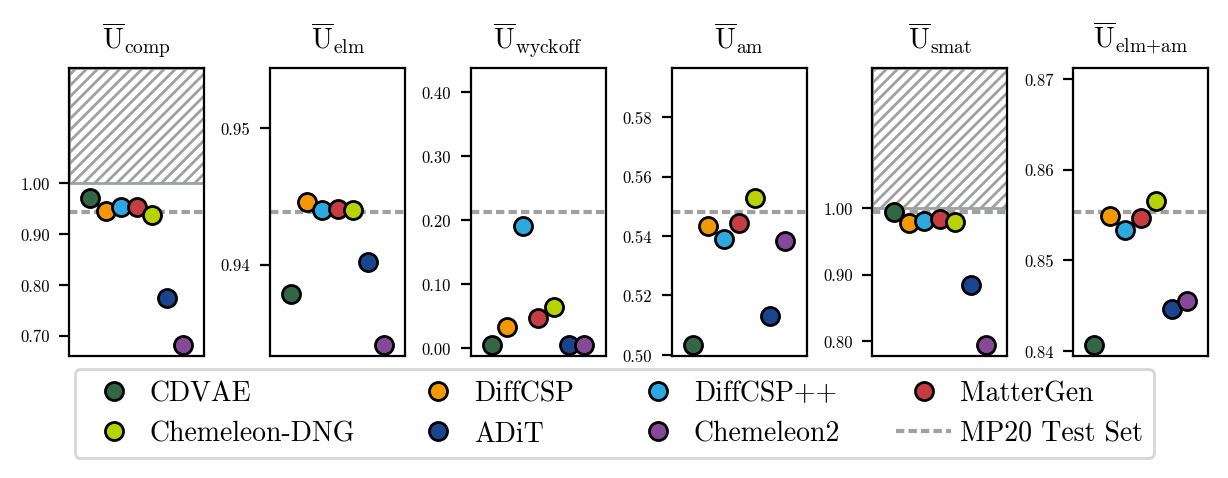

In [16]:
# Figure 3
stripplot(df_uni, "Uniqueness score", "uni.pdf", U_LABELS)

In [17]:
# Table S2
table_ranking(df_nov, "Novelty score", MODELS_TEST)

+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| model    | cdvae      | diffcsp    | diffcsppp   | mattergen   | chemeleon   | adit       | chemeleon2   |   test |
+==========+============+============+=============+=============+=============+============+==============+========+
| comp     | 0.9221 (1) | 0.8207 (2) | 0.8121 (4)  | 0.8156 (3)  | 0.7497 (6)  | 0.2352 (7) | 0.8090 (5)   | 0.7904 |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| elmd     | 0.5230 (1) | 0.3954 (2) | 0.3951 (3)  | 0.3883 (4)  | 0.3306 (6)  | 0.0655 (7) | 0.3348 (5)   | 0.1973 |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| wyckoff  | 0.0352 (6) | 0.0814 (3) | 0.0098 (7)  | 0.0967 (2)  | 0.1137 (1)  | 0.0425 (4) | 0.0371 (5)   | 0.05   |
+----------+------------+------------+-------------+----

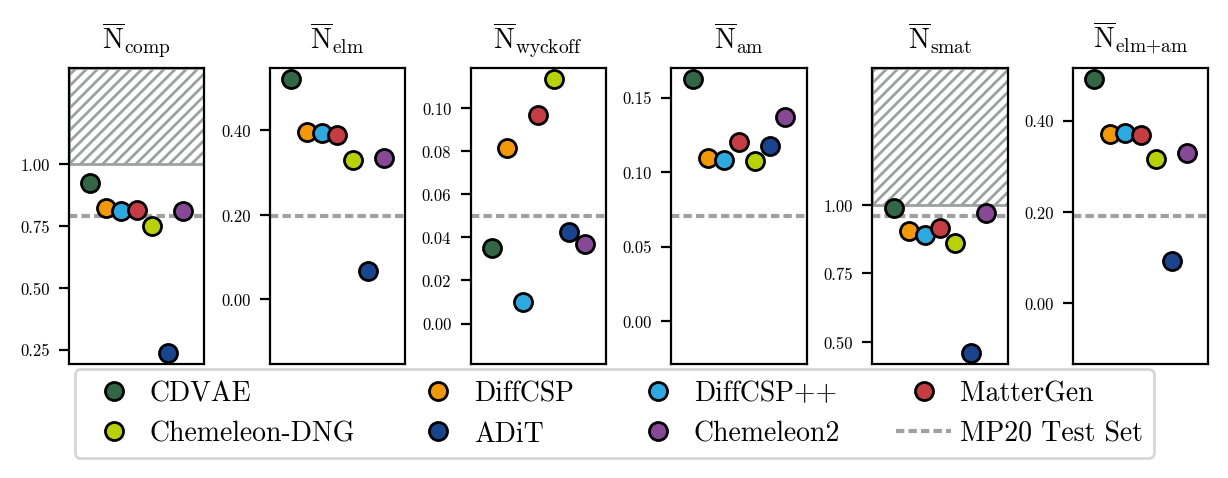

In [18]:
# Figure 4
stripplot(df_nov, "Novelty score", "nov.pdf", N_LABELS)

In [19]:
def nov_samples_and_neighbors(model, distance, k=5):
	mtx_nov = load_gz(os.path.join(RESULTS_DIR, model, f"mtx_nov_{distance}.pkl.gz"))
	val_smact_all = load_gz(os.path.join(RESULTS_DIR, model, "val_smact.pkl.gz"))
	val_structure_all = load_gz(
		os.path.join(RESULTS_DIR, model, "val_structure.pkl.gz")
	)
	ehull_all = load_gz(os.path.join(RESULTS_DIR, model, "ehull.pkl.gz"))
	nov_all = np.min(mtx_nov, axis=1)
	nov_all[np.isnan(nov_all)] = 0
	indices_neighbors = np.argmin(mtx_nov, axis=1)
	nov_indices = np.argsort(nov_all)[-k:][::-1]
	nov = nov_all[nov_indices]
	val_smact = val_smact_all[nov_indices]
	val_structure = val_structure_all[nov_indices]
	ehull = ehull_all[nov_indices]
	nov_samples = [SAMPLES[model][i] for i in nov_indices]
	nov_neighbors = [TRAIN_SAMPLES[indices_neighbors[i]] for i in nov_indices]
	return nov, val_smact, val_structure, ehull, nov_samples, nov_neighbors


Novelty score: 0.7757, SMACT val: 0.0000, Structure val: 1.0000, Ehull: 0.5338, Space group: Cm (8), Crystal system: monoclinic
--------------------------------------------------------------------------------
Novelty score: 0.7711, SMACT val: 1.0000, Structure val: 1.0000, Ehull: 0.8257, Space group: P1 (1), Crystal system: triclinic
--------------------------------------------------------------------------------
Novelty score: 0.7689, SMACT val: 1.0000, Structure val: 1.0000, Ehull: 0.6765, Space group: P1 (1), Crystal system: triclinic
--------------------------------------------------------------------------------
Novelty score: 0.7682, SMACT val: 1.0000, Structure val: 1.0000, Ehull: 0.6657, Space group: P1 (1), Crystal system: triclinic
--------------------------------------------------------------------------------
Novelty score: 0.7666, SMACT val: 1.0000, Structure val: 1.0000, Ehull: 0.2781, Space group: P1 (1), Crystal system: triclinic
----------------------------------------

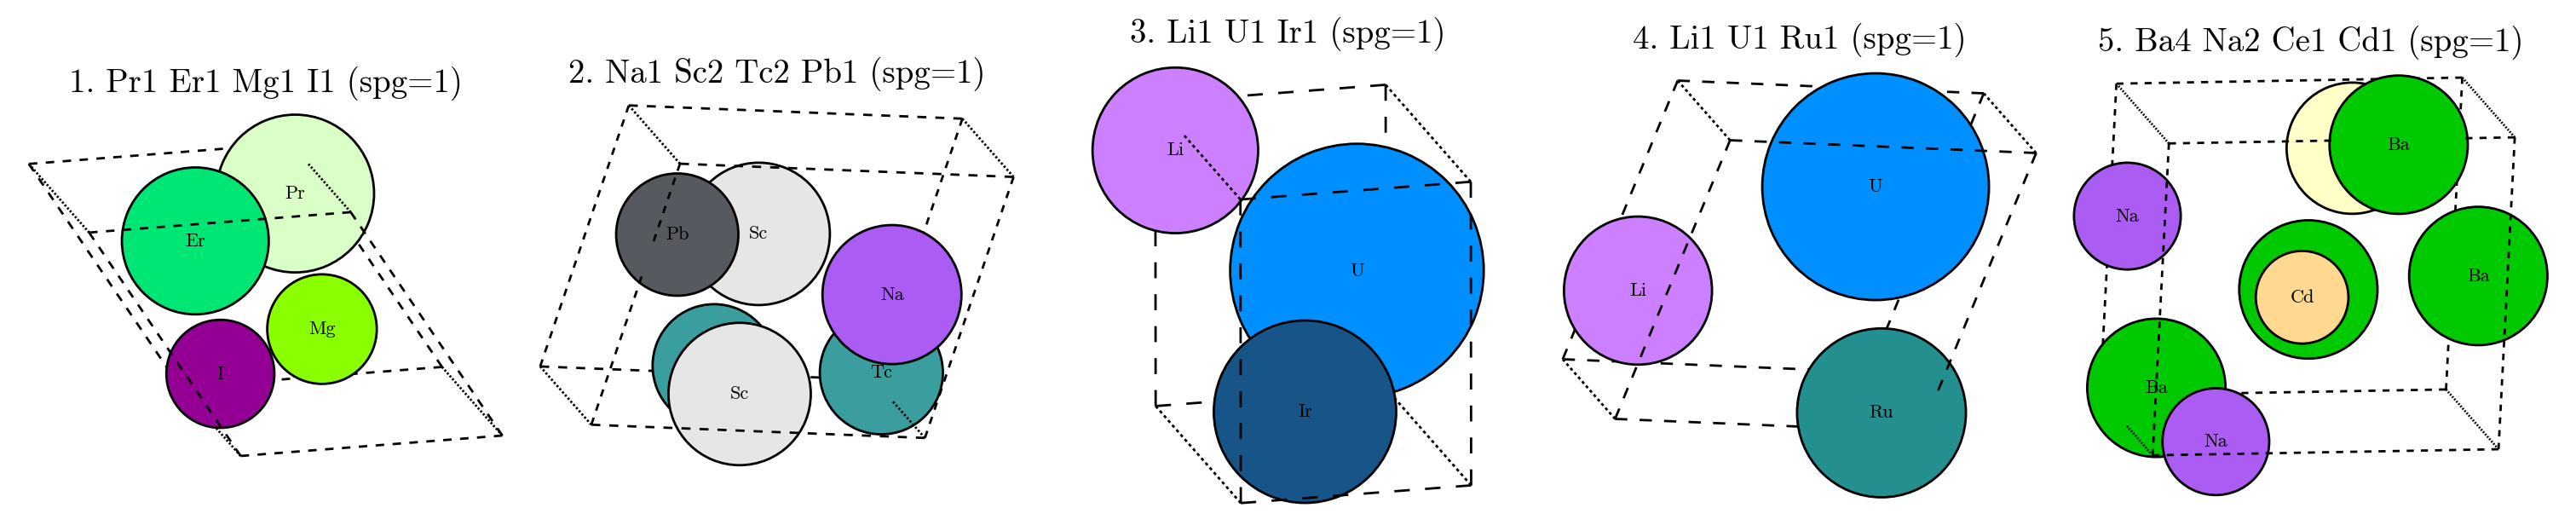

In [20]:
# Figure 5
nov, val_smact, val_structure, ehull, nov_samples, nov_neighbors = (
	nov_samples_and_neighbors("cdvae", "elmd+amd", k=5)
)
for i_nov, i_smact, i_struct, i_ehull, gen in zip(
	nov, val_smact, val_structure, ehull, nov_samples, strict=False
):
	sga = SpacegroupAnalyzer(gen, symprec=0.1)
	print(
		f"Novelty score: {i_nov:.4f}, SMACT val: {i_smact:.4f}, Structure val: {i_struct:.4f}, Ehull: {i_ehull:.4f}, Space group: {sga.get_space_group_symbol()} ({sga.get_space_group_number()}), Crystal system: {sga.get_crystal_system()}"
	)
	print("-" * 80)
pymatviz.structure_2d(
	nov_samples,
	n_cols=5,
)
for idx, gen in enumerate(nov_samples):
	gen.to_file(os.path.join(FIGURES_DIR, f"cdvae_elm+am_nov_{idx}.cif"))

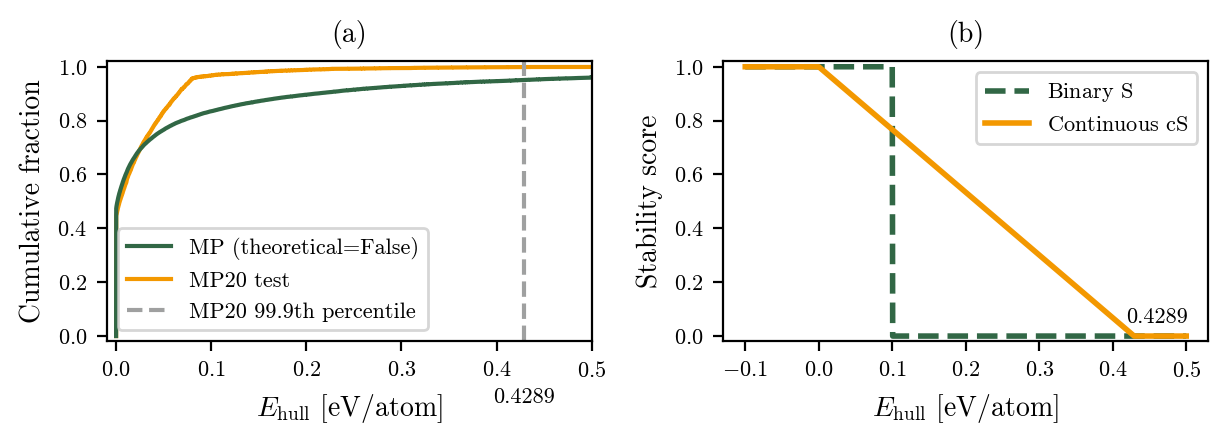

In [21]:
# Figure 6
fig, axes = plt.subplots(
	1, 2, figsize=(FIG_WIDTH, 0.35 * FIG_WIDTH), gridspec_kw={"wspace": 0.05}
)

# cumulative ditribution of Ehull
df = pd.DataFrame(
	{
		"energy_above_hull": np.concatenate(
			(
				ehulls_mp_experimental,
				ehulls_mp20_test[~np.isnan(ehulls_mp20_test)],
			)
		),
		"source": ["MP (theoretical=False)"] * len(ehulls_mp_experimental)
		+ ["MP20 test"] * np.sum(~np.isnan(ehulls_mp20_test)),
	}
)
sns.ecdfplot(data=df, x="energy_above_hull", hue="source", ax=axes[0])
sns_legend = axes[0].get_legend()
handles = sns_legend.legend_handles
labels = [t.get_text() for t in sns_legend.get_texts()]
n_non_nan = np.sum(~np.isnan(ehulls_mp20_test))
percentile = np.sort(ehulls_mp20_test[~np.isnan(ehulls_mp20_test)])[
	int(0.999 * n_non_nan) - 1
]
line_percentile = axes[0].axvline(
	percentile,
	linestyle="--",
	color=GRAY,
)
axes[0].text(
	percentile,
	-0.25,
	f"{percentile:.4f}",
	horizontalalignment="center",
	fontsize=FONT_M,
)
axes[0].set_xlim(-0.01, 0.5)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_xlabel(r"$E_\mathrm{hull}$ [eV/atom]", fontsize=FONT_L, labelpad=PAD_S)
axes[0].set_ylabel("Cumulative fraction", fontsize=FONT_L)
axes[0].tick_params(axis="both", labelsize=FONT_M)
handles.append(line_percentile)
labels.append("MP20 99.9th percentile")
axes[0].legend(
	handles,
	labels,
	fontsize=FONT_M,
)
axes[0].set_title("(a)", fontsize=FONT_L, pad=PAD_M)

# stability score functions
x = np.linspace(-0.1, 0.5, 1000)
y1 = np.where(x <= 0.1, 1, 0)
y2 = np.clip(1 - x / STABILITY_INTERCEPT, 0, 1)

axes[1].plot(x, y1, label=r"Binary $\mathrm{S}$", linestyle="--", linewidth=2)
axes[1].plot(x, y2, label=r"Continuous $\mathrm{cS}$", linestyle="-", linewidth=2)
axes[1].set_ylim(-0.02, 1.02)
axes[1].text(
	0.46, 0.05, f"{percentile:.4f}", horizontalalignment="center", fontsize=FONT_M
)
axes[1].set_xlabel(r"$E_\mathrm{hull}$ [eV/atom]", fontsize=FONT_L, labelpad=PAD_S)
axes[1].set_ylabel("Stability score", fontsize=FONT_L)
axes[1].legend(fontsize=FONT_M)
axes[1].tick_params(axis="both", labelsize=FONT_M)
axes[1].set_title("(b)", fontsize=FONT_L, pad=PAD_M)

plt.savefig(os.path.join(FIGURES_DIR, "ehull_stability.pdf"), bbox_inches="tight")


In [22]:
def build_df_stab(model_list):
	rows = [
		(model, e)
		for model in model_list
		for e in load_gz(os.path.join(RESULTS_DIR, model, "ehull.pkl.gz"))
	]
	df = pd.DataFrame(rows, columns=["Model", "Energy above the convex hull [eV/atom]"])
	df["Binary stability score"] = (
		df["Energy above the convex hull [eV/atom]"] <= 0.1
	).astype(int)
	df["Continuous stability score"] = np.clip(
		1 - df["Energy above the convex hull [eV/atom]"] / STABILITY_INTERCEPT, 0, 1
	)
	return df


df_stab = build_df_stab(MODELS_TEST)


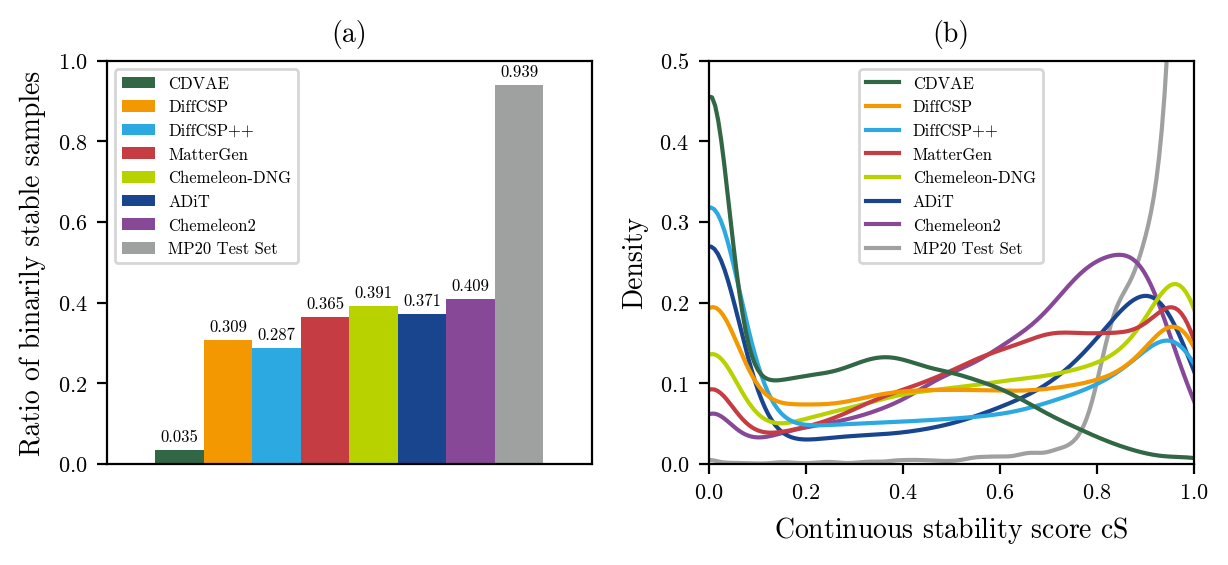

In [23]:
# Figure 7
fig, axes = plt.subplots(
	1, 2, figsize=(FIG_WIDTH, 0.45 * FIG_WIDTH), gridspec_kw={"wspace": 0.05}
)

# binary stability
models = []
binary_stability_scores = []
for model in MODELS_TEST:
	models.append(model)
	e = df_stab.loc[
		df_stab["Model"] == model, "Energy above the convex hull [eV/atom]"
	].values
	binary_stability_scores.append(
		df_stab.loc[df_stab["Model"] == model, "Binary stability score"].values.mean()
	)
df = pd.DataFrame(
	{
		"Model": models,
		"Binary stability score": binary_stability_scores,
	}
)
sns.barplot(
	df,
	y="Binary stability score",
	hue="Model",
	ax=axes[0],
	saturation=1.0,
)
for container in axes[0].containers:
	axes[0].bar_label(
		container, fmt="%.3f", label_type="edge", padding=PAD_SS, fontsize=FONT_S
	)
axes[0].set_xlabel("")
axes[0].set_ylabel("Ratio of binarily stable samples", fontsize=FONT_L)
axes[0].tick_params(axis="both", labelsize=FONT_M)
axes[0].set_xticks([])
axes[0].set_ylim(0, 1.05)
handles, labels = axes[0].get_legend_handles_labels()
labels = [MODEL_TEST_LABELS[label] for label in labels]
axes[0].legend(
	handles,
	labels,
	fontsize=FONT_S,
)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_title("(a)", fontsize=FONT_L, pad=PAD_M)

# continuous stability
sns.kdeplot(
	data=df_stab,  # [df_stab["Model"] != "test"],
	x="Continuous stability score",
	hue="Model",
	ax=axes[1],
	alpha=1.0,
)
axes[1].set_xlabel(r"Continuous stability score $\mathrm{cS}$", fontsize=FONT_L)
axes[1].set_ylabel("Density", fontsize=FONT_L)
axes[1].tick_params(axis="both", labelsize=FONT_M)
legend = axes[1].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
labels = [MODEL_TEST_LABELS[label] for label in labels]
axes[1].legend(
	handles,
	labels,
	fontsize=FONT_S,
)
axes[1].set_ylim(0.0, 0.5)
axes[1].set_xlim(0.0, 1.0)
axes[1].set_title("(b)", fontsize=FONT_L, pad=PAD_M)

plt.savefig(os.path.join(FIGURES_DIR, "stability_b_c.pdf"), bbox_inches="tight")



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



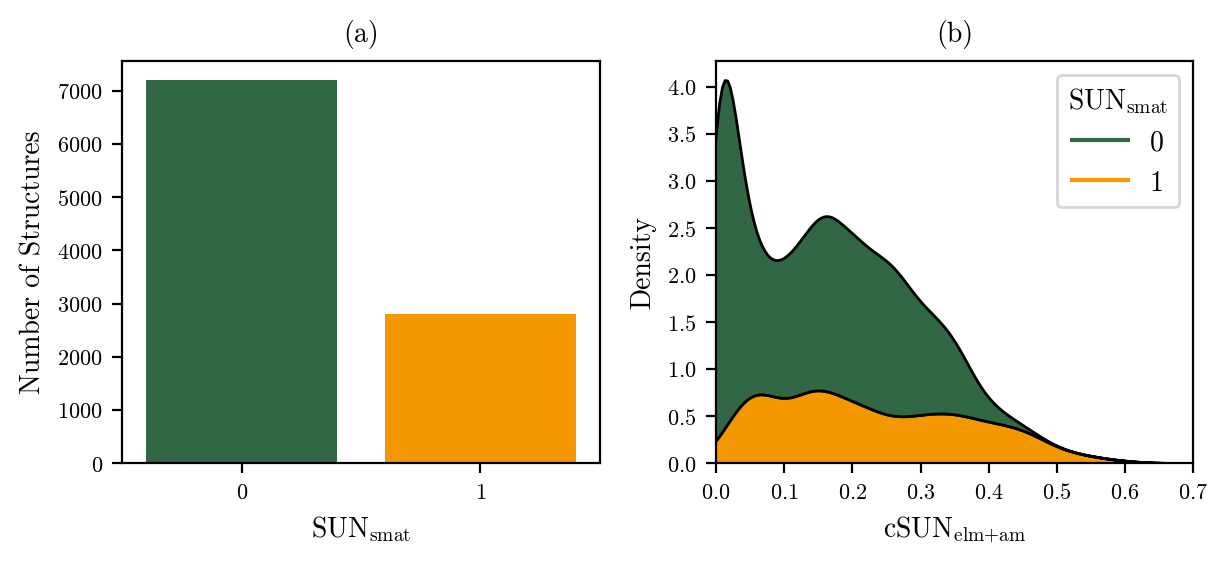

In [24]:
# Figure 8
fig, axes = plt.subplots(
	1, 2, figsize=(FIG_WIDTH, 0.45 * FIG_WIDTH), gridspec_kw={"wspace": 0.05}
)

# binary sun
sun = (
	df_stab[df_stab["Model"] == "mattergen"]["Binary stability score"].values
	* df_uni[(df_uni["Model"] == "mattergen") & (df_uni["Distance"] == "smat")][
		"Uniqueness score"
	].values
	* df_nov[(df_nov["Model"] == "mattergen") & (df_nov["Distance"] == "smat")][
		"Novelty score"
	].values
)
n_sun = np.sum(sun)
n_not_sun = len(sun) - n_sun
sns.barplot(
	x=["0", "1"],
	y=[n_not_sun, n_sun],
	ax=axes[0],
	palette={"0": sns.color_palette()[0], "1": sns.color_palette()[1]},
	saturation=1.0,
)
axes[0].set_xlabel(r"$\mathrm{SUN}_\mathrm{smat}$", fontsize=FONT_L)
axes[0].set_ylabel("Number of Structures", fontsize=FONT_L)
axes[0].tick_params(axis="both", labelsize=FONT_M)
axes[0].set_title("(a)", fontsize=FONT_L, pad=PAD_M)

# continuous sun
csun = (
	df_stab[df_stab["Model"] == "mattergen"]["Continuous stability score"].values
	* df_uni[(df_uni["Model"] == "mattergen") & (df_uni["Distance"] == "elmd+amd")][
		"Uniqueness score"
	].values
	* df_nov[(df_nov["Model"] == "mattergen") & (df_nov["Distance"] == "elmd+amd")][
		"Novelty score"
	].values
)
df_sun_csun = pd.DataFrame(
	{
		"SUN": sun,
		"cSUN": csun,
	}
)
sns.kdeplot(df_sun_csun, x="cSUN", hue="SUN", multiple="stack", ax=axes[1], alpha=1.0)
axes[1].set_xlabel(r"$\mathrm{cSUN}_\mathrm{elm{+}am}$", fontsize=FONT_L)
axes[1].set_ylabel("Density", fontsize=FONT_L)
axes[1].tick_params(axis="both", labelsize=FONT_M)
axes[1].set_xlim(0.0, 0.7)
legend = axes[1].get_legend()
axes[1].legend(
	handles,
	[0, 1],
	title=r"$\mathrm{SUN}_\mathrm{smat}$",
	title_fontsize=FONT_L,
	fontsize=FONT_L,
)
axes[1].set_title("(b)", fontsize=FONT_L, pad=PAD_M)

plt.savefig(os.path.join(FIGURES_DIR, "sun_b_c.pdf"), bbox_inches="tight")

In [25]:
def build_df_sun(model_list, df_stab):
	models, distances, ehulls, uni_scores, nov_scores, sun_scores = (
		[],
		[],
		[],
		[],
		[],
		[],
	)
	for model in model_list:
		for distance in DISTANCES:
			n_samples = len(df_stab[df_stab["Model"] == model])
			models.extend([model] * n_samples)
			distances.extend([distance] * n_samples)
			ehulls_sub = df_stab[df_stab["Model"] == model][
				"Energy above the convex hull [eV/atom]"
			].values
			uni_sub = df_uni[
				(df_uni["Model"] == model) & (df_uni["Distance"] == distance)
			]["Uniqueness score"].values
			nov_sub = df_nov[
				(df_nov["Model"] == model) & (df_nov["Distance"] == distance)
			]["Novelty score"].values
			ehulls.extend(ehulls_sub.tolist())
			uni_scores.extend(uni_sub.tolist())
			nov_scores.extend(nov_sub.tolist())
			if distance in BINARY_DISTANCES:
				stab_scores = (ehulls_sub <= 0.1).astype(float)
			else:
				stab_scores = np.clip(
					1 - np.array(ehulls_sub) / STABILITY_INTERCEPT, 0, 1
				)
			sun_scores.extend((stab_scores * uni_sub * nov_sub).tolist())
	ehulls = np.array(ehulls)
	return pd.DataFrame(
		{
			"Model": models,
			"Distance": distances,
			"Binary Stability": (ehulls <= 0.1).astype(float),
			"Continuous Stability (intercept=0.4289)": np.clip(
				1 - ehulls / STABILITY_INTERCEPT, 0, 1
			),
			"Uniqueness": uni_scores,
			"Novelty": nov_scores,
			"SUN score": sun_scores,
		}
	)


df_sun = build_df_sun(MODELS_TEST, df_stab)


In [26]:
# Table S3
table_ranking(df_sun, "SUN score", MODELS_TEST)

+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| model    | cdvae      | diffcsp    | diffcsppp   | mattergen   | chemeleon   | adit       | chemeleon2   |   test |
+==========+============+============+=============+=============+=============+============+==============+========+
| comp     | 0.0290 (7) | 0.1741 (4) | 0.1551 (5)  | 0.2234 (1)  | 0.2078 (2)  | 0.0565 (6) | 0.1932 (3)   | 0.73   |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| elmd     | 0.1188 (5) | 0.1371 (4) | 0.0938 (6)  | 0.1891 (2)  | 0.1410 (3)  | 0.0178 (7) | 0.1896 (1)   | 0.1714 |
+----------+------------+------------+-------------+-------------+-------------+------------+--------------+--------+
| wyckoff  | 0.0000 (7) | 0.0071 (3) | 0.0010 (6)  | 0.0149 (1)  | 0.0138 (2)  | 0.0012 (4) | 0.0011 (5)   | 0.042  |
+----------+------------+------------+-------------+----

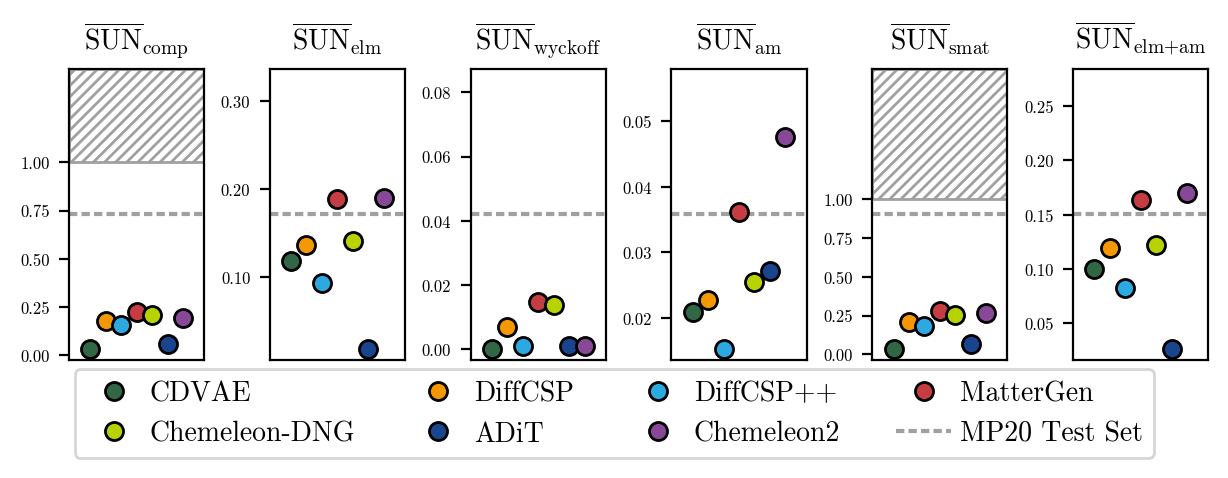

In [27]:
# Figure 9
stripplot(df_sun, "SUN score", "sun.pdf", SUN_LABELS)

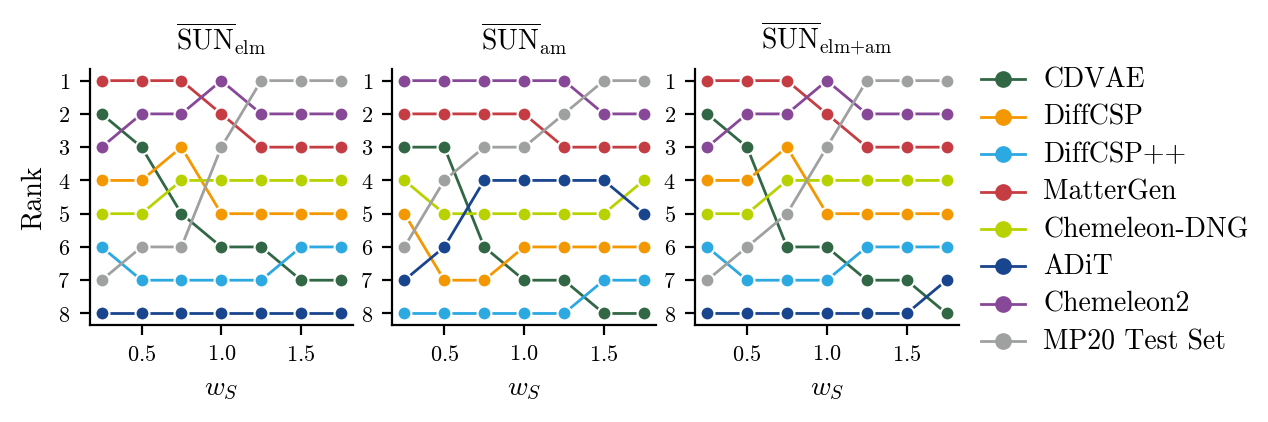

In [29]:
# Figure 10
wss = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75]
data = []
for distance in CONTINUOUS_DISTANCES:
	for ws in wss:
		scores = []
		for model in MODELS_TEST:
			df_part = df_sun[
				(df_sun["Distance"] == distance) & (df_sun["Model"] == model)
			]
			sun = (
				df_part[f"Continuous Stability (intercept={STABILITY_INTERCEPT})"] ** ws
				* df_part["Uniqueness"]
				* df_part["Novelty"] ** (2 - ws)
			)
			sun[np.isnan(sun)] = 0
			scores.append(np.mean(sun).item())
		ranks = np.argsort(-np.array(scores))
		for i in range(len(MODELS_TEST)):
			data.append(
				{
					"Model": MODEL_TEST_LABELS[MODELS_TEST[ranks[i]]],
					"Distance": distance,
					"ws": ws,
					"Rank": i + 1,
				}
			)
df = pd.DataFrame(data)
g = sns.relplot(
	data=df,
	x="ws",
	y="Rank",
	hue="Model",
	col="Distance",
	kind="line",
	marker="o",
	markersize=5,
	linewidth=1,
	facet_kws={
		"sharey": False,
	},
	col_wrap=3,
	hue_order=[MODEL_TEST_LABELS[model] for model in MODELS_TEST],
)

g.fig.set_size_inches(FIG_WIDTH, 0.25 * FIG_WIDTH)
for ax in g.axes.flat:
	ax.invert_yaxis()
	ax.set_yticks(range(1, len(MODELS_TEST) + 1))
	ax.tick_params(axis="both", labelsize=FONT_M)
	ax.set_xlabel(r"$w_S$", fontsize=FONT_L)
	ax.set_title(SUN_LABELS[ax.get_title().split(" = ")[1]], fontsize=FONT_L, pad=PAD_M)
g._legend.set_title("")
plt.setp(g._legend.get_texts(), fontsize=FONT_L)
g.axes[0].set_ylabel("Rank", fontsize=FONT_L)
g.fig.subplots_adjust(right=0.75, wspace=0.15)
plt.savefig(os.path.join(FIGURES_DIR, "sun_weight.pdf"), bbox_inches="tight")

In [30]:
def sun_samples_and_neighbors(model, distance, k=5):
	mtx_uni = load_gz(os.path.join(RESULTS_DIR, model, f"mtx_uni_{distance}.pkl.gz"))
	mtx_nov = load_gz(os.path.join(RESULTS_DIR, model, f"mtx_nov_{distance}.pkl.gz"))
	val_smact = load_gz(os.path.join(RESULTS_DIR, model, "val_smact.pkl.gz"))
	val_structure = load_gz(os.path.join(RESULTS_DIR, model, "val_structure.pkl.gz"))
	ehulls = load_gz(os.path.join(RESULTS_DIR, model, "ehull.pkl.gz"))
	stab_scores = np.clip(1 - ehulls / STABILITY_INTERCEPT, 0, 1)
	uni_scores = np.sum(mtx_uni, axis=1) / mtx_uni.shape[1]
	nov_scores = np.min(mtx_nov, axis=1)
	scores = val_smact * val_structure * stab_scores * uni_scores * nov_scores
	scores[np.isnan(scores)] = 0
	indices_neighbors = np.argmin(mtx_nov, axis=1)
	nov_indices = np.argsort(scores)[-k:][::-1]
	return (
		uni_scores[nov_indices],
		nov_scores[nov_indices],
		ehulls[nov_indices],
		val_smact[nov_indices],
		val_structure[nov_indices],
		[SAMPLES[model][i] for i in nov_indices],
		[TRAIN_SAMPLES[indices_neighbors[i]] for i in nov_indices],
	)


Uniqueness score: 0.8763, Novelty score: 0.7217, Ehull: -0.0222, SMACT val: 1.0000, Structure val: 1.0000, Space group: C2/m (12), Crystal system: monoclinic
--------------------------------------------------------------------------------
Uniqueness score: 0.8829, Novelty score: 0.7179, Ehull: 0.0274, SMACT val: 1.0000, Structure val: 1.0000, Space group: P-3m1 (164), Crystal system: trigonal
--------------------------------------------------------------------------------
Uniqueness score: 0.9006, Novelty score: 0.7411, Ehull: 0.0503, SMACT val: 1.0000, Structure val: 1.0000, Space group: P-6m2 (187), Crystal system: hexagonal
--------------------------------------------------------------------------------
Uniqueness score: 0.8776, Novelty score: 0.6828, Ehull: 0.0079, SMACT val: 1.0000, Structure val: 1.0000, Space group: Im-3m (229), Crystal system: cubic
--------------------------------------------------------------------------------
Uniqueness score: 0.8951, Novelty score: 0.7153, 

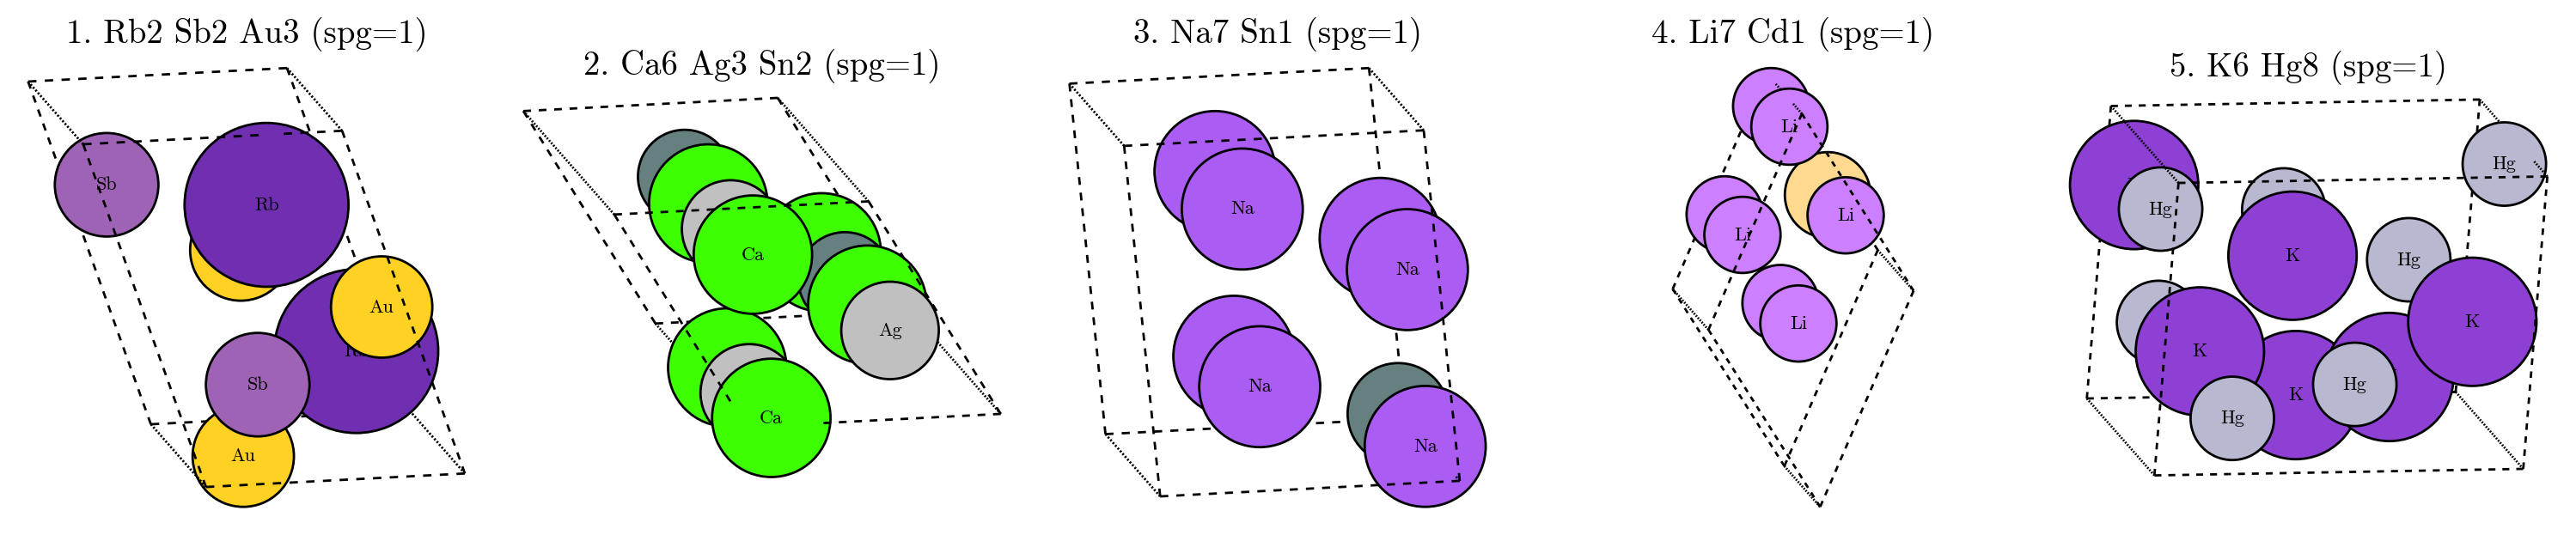

In [31]:
# Figure 11
(
	nov_uni_scores,
	nov_nov_scores,
	nov_ehulls,
	nov_val_smact,
	nov_val_structure,
	nov_samples,
	nov_neighbors,
) = sun_samples_and_neighbors("mattergen", "elmd+amd", k=5)
for i_uni, i_nov, i_ehull, i_smact, i_struct, gen in zip(
	nov_uni_scores,
	nov_nov_scores,
	nov_ehulls,
	nov_val_smact,
	nov_val_structure,
	nov_samples,
	strict=False,
):
	sga = SpacegroupAnalyzer(gen, symprec=0.1)
	print(
		f"Uniqueness score: {i_uni:.4f}, Novelty score: {i_nov:.4f}, Ehull: {i_ehull:.4f}, SMACT val: {i_smact:.4f}, Structure val: {i_struct:.4f}, Space group: {sga.get_space_group_symbol()} ({sga.get_space_group_number()}), Crystal system: {sga.get_crystal_system()}"
	)
	print("-" * 80)
pymatviz.structure_2d(
	nov_samples,
	n_cols=5,
)
for idx, gen in enumerate(nov_samples):
	gen.to_file(os.path.join(FIGURES_DIR, f"mattergen_elm+am_vsun_{idx}.cif"))

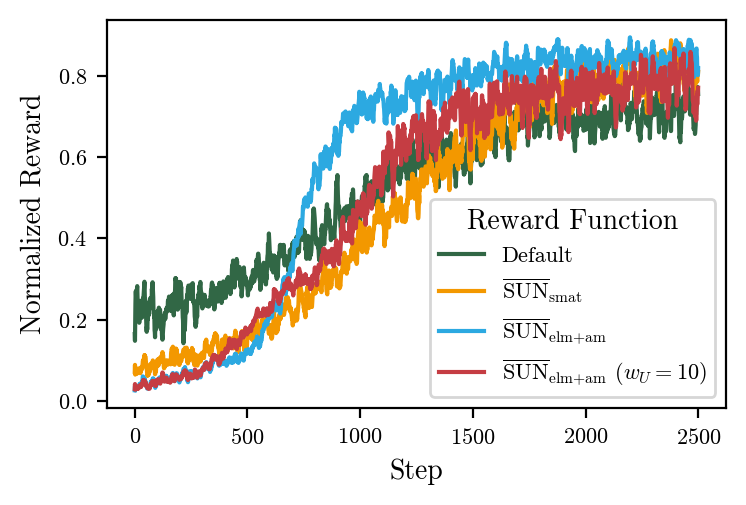

In [ ]:
# Figure 12
df_raw = pd.read_csv(os.path.join(RESULTS_DIR, "../wangyq_rl.csv"))
n_step = len(df_raw)
step = list(range(n_step)) * 4
reward_name = (
	[MODEL_RL_TEST_LABELS["chemeleon2"]] * n_step
	+ [MODEL_RL_TEST_LABELS["chemeleon2_rl_bsun"]] * n_step
	+ [MODEL_RL_TEST_LABELS["chemeleon2_rl_csun"]] * n_step
	+ [MODEL_RL_TEST_LABELS["chemeleon2_rl_csun_u10"]] * n_step
)
reward_value = []
for col_name in [
	"rl_default_reward - train/reward",
	"rl_bsun_reward - train/reward",
	"rl_csun_reward - train/reward",
	"rl_csun_reward_u10 - train/reward",
]:
	reward_raw = df_raw[col_name].values
	normalized_reward = (reward_raw - np.min(reward_raw)) / (
		np.max(reward_raw) - np.min(reward_raw)
	)
	# average over last 10 steps
	for i in range(n_step):
		if i < 10:
			reward_value.append(np.mean(normalized_reward[: i + 1]).item())
		else:
			reward_value.append(np.mean(normalized_reward[i - 9 : i + 1]).item())
df = pd.DataFrame(
	{
		"Step": step,
		"Reward Function": reward_name,
		"Reward Value": reward_value,
	}
)
plt.figure(figsize=(0.6 * FIG_WIDTH, 0.4 * FIG_WIDTH))
sns.lineplot(
	data=df,
	x="Step",
	y="Reward Value",
	hue="Reward Function",
)
plt.xlabel("Step", fontsize=FONT_L)
plt.ylabel("Normalized Reward", fontsize=FONT_L)
plt.tick_params(axis="both", labelsize=FONT_M)
legend = plt.gca().get_legend()
legend.set_title(legend.get_title().get_text(), prop={"size": FONT_L})
for text in legend.get_texts():
	text.set_fontsize(FONT_M)
plt.savefig(os.path.join(FIGURES_DIR, "rl_train_dynamics.pdf"), bbox_inches="tight")

In [33]:
df_stab = build_df_stab(MODELS_RL_TEST)
df_sun = build_df_sun(MODELS_RL_TEST, df_stab)


In [34]:
# Table 4
table_ranking(df_sun, "SUN score", MODELS_RL_TEST)

+----------+--------------+----------------------+----------------------+--------------------------+--------+
| model    | chemeleon2   | chemeleon2_rl_bsun   | chemeleon2_rl_csun   | chemeleon2_rl_csun_u10   |   test |
+==========+==============+======================+======================+==========================+========+
| comp     | 0.1932 (2)   | 0.3544 (1)           | 0.0250 (4)           | 0.1752 (3)               | 0.73   |
+----------+--------------+----------------------+----------------------+--------------------------+--------+
| elmd     | 0.1896 (4)   | 0.3885 (3)           | 0.6152 (2)           | 0.6549 (1)               | 0.1714 |
+----------+--------------+----------------------+----------------------+--------------------------+--------+
| wyckoff  | 0.0011 (3)   | 0.0014 (1)           | 0.0007 (4)           | 0.0014 (2)               | 0.042  |
+----------+--------------+----------------------+----------------------+--------------------------+--------+
| amd     

In [35]:
# Table 5
path = hf_hub_download(
	repo_id="masahiro-negishi/xtalmet",
	filename="mp20/train/train_comp.pkl.gz",
	repo_type="dataset",
	revision=HF_VERSION,
)
train_embs = load_gz(path)
train_emb_cnt = Counter(train_embs)

for model in MODELS_RL_TEST:
	embs = load_gz(os.path.join(RESULTS_DIR, model, "emb_comp.pkl.gz"))
	emb_cnt = Counter(embs)
	print(f"Model: {model}")
	print(f"  Total unique embeddings: {len(emb_cnt)}")
	for idx, (emb, cnt) in enumerate(emb_cnt.most_common()):
		train_cnt = train_emb_cnt.get(emb, 0)
		comp = "".join(f"{elm[0]}{elm[1]}" for elm in emb)
		print(
			f"  Embedding: {emb}, Count: {cnt}, Train Count: {train_cnt}, SMACT: {smact_validity(comp)}"
		)
		if idx >= 3:
			break
	print()


Model: chemeleon2
  Total unique embeddings: 6807
  Embedding: (('K', 1),), Count: 37, Train Count: 8, SMACT: True
  Embedding: (('Co', 4), ('Li', 3), ('O', 8)), Count: 22, Train Count: 1, SMACT: False
  Embedding: (('Ga', 1), ('Tb', 1), ('Zn', 1)), Count: 21, Train Count: 0, SMACT: True
  Embedding: (('Eu', 1), ('O', 2), ('Sr', 1)), Count: 19, Train Count: 1, SMACT: True

Model: chemeleon2_rl_bsun
  Total unique embeddings: 4067
  Embedding: (('Gd', 5), ('Ir', 2)), Count: 611, Train Count: 0, SMACT: True
  Embedding: (('Ac', 4), ('Pt', 1)), Count: 141, Train Count: 0, SMACT: True
  Embedding: (('Ac', 12), ('Ni', 6), ('Pb', 1)), Count: 86, Train Count: 0, SMACT: True
  Embedding: (('Ca', 7), ('Pd', 3)), Count: 34, Train Count: 0, SMACT: True

Model: chemeleon2_rl_csun
  Total unique embeddings: 287
  Embedding: (('Cs', 1), ('Hg', 5)), Count: 900, Train Count: 0, SMACT: True
  Embedding: (('Ac', 1), ('Hg', 2), ('Sc', 1)), Count: 750, Train Count: 0, SMACT: True
  Embedding: (('Cs', 6), 